In [1]:
!pip install "protobuf<4.21.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 4.3 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
a2a-sdk 0.3.25 requires protobuf>=5.29.5, but you have protobuf 3.20.3 which is incompatible.
onnx 1.20.1 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.17.3 requires protobuf>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 wh

In [2]:
# ==========================================
# CELL 1: DATA PIPELINE & PREPROCESSING
# ==========================================
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import kagglehub

# 1. Setup & Functions
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CHANNELS = 3
AUTOTUNE = tf.data.AUTOTUNE

def custom_cutout(image, mask_size=40):
    img_height, img_width, _ = image.shape
    y = tf.random.uniform([], 0, img_height, dtype=tf.int32)
    x = tf.random.uniform([], 0, img_width, dtype=tf.int32)
    y1 = tf.clip_by_value(y - mask_size // 2, 0, img_height)
    y2 = tf.clip_by_value(y + mask_size // 2, 0, img_height)
    x1 = tf.clip_by_value(x - mask_size // 2, 0, img_width)
    x2 = tf.clip_by_value(x + mask_size // 2, 0, img_width)
    mask = np.ones((img_height, img_width, 3), dtype=np.float32)
    mask[y1:y2, x1:x2, :] = 0.0
    return image * mask

def prepare_dataset(df, shuffle=True, augment=True):
    def parse_image(file_path, label):
        img = tf.io.read_file(file_path)
        img = tf.image.decode_jpeg(img, channels=CHANNELS)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32) / 255.0
        # CRITICAL FIX: Explicitly set the shape for Multi-GPU Strategy
        img.set_shape([IMG_SIZE[0], IMG_SIZE[1], CHANNELS]) 
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((df['file_path'].values, df['label'].values))
    ds = ds.map(parse_image, num_parallel_calls=AUTOTUNE)
    
    if shuffle:
        ds = ds.shuffle(buffer_size=1000)
        
    if augment:
        ds = ds.map(lambda x, y: (tf.image.random_flip_left_right(x), y), num_parallel_calls=AUTOTUNE)
        # Wrapper to restore shape metadata after numpy/py_function operations
        def apply_cutout(x, y):
            x_out = tf.py_function(custom_cutout, [x], tf.float32)
            x_out.set_shape([IMG_SIZE[0], IMG_SIZE[1], CHANNELS])
            return x_out, y
        ds = ds.map(apply_cutout, num_parallel_calls=AUTOTUNE)
        
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# 2. Download Dataset
print("Downloading/Locating PlantVillage dataset...")
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")
base_dir = path
for root, dirs, files in os.walk(path):
    if 'color' in root.lower() and len(dirs) > 0:
        base_dir = root
        break

# 3. Extract Filepaths & Labels
filepaths = []
labels = []
class_names = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))])
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
NUM_CLASSES = len(class_names) 

for class_name in class_names:
    class_dir = os.path.join(base_dir, class_name)
    for img_file in os.listdir(class_dir):
        if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
            filepaths.append(os.path.join(class_dir, img_file))
            labels.append(class_to_idx[class_name])

df = pd.DataFrame({'file_path': filepaths, 'label': labels})

# 4. Split Data & Build Pipelines
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

train_ds = prepare_dataset(train_df, shuffle=True, augment=True)
val_ds = prepare_dataset(val_df, shuffle=False, augment=False)
test_ds = prepare_dataset(test_df, shuffle=False, augment=False)

print(f"\n✅ Cell 1 Complete! Found {NUM_CLASSES} classes.")

2026-04-01 19:46:15.529236: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775072775.713929      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775072775.769941      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775072776.191589      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775072776.191635      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775072776.191638      55 computation_placer.cc:177] computation placer alr

Downloading/Locating PlantVillage dataset...


I0000 00:00:1775073061.475143      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775073061.481107      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



✅ Cell 1 Complete! Found 38 classes.


In [3]:
# ==========================================
# CELL 2: ARCHITECTURE & T4x2 MULTI-GPU SETUP
# ==========================================
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers
from tensorflow.keras import mixed_precision

# 1. Hardware Optimization for T4 GPUs (Tensor Cores)
print("Configuring hardware optimizations...")
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print(f"Compute dtype: {policy.compute_dtype}")
print(f"Variable dtype: {policy.variable_dtype}")

# 2. Multi-GPU Strategy Setup
strategy = tf.distribute.MirroredStrategy()
print(f"Number of GPUs being used: {strategy.num_replicas_in_sync}")

# 3. Attention Mechanism Definitions
def se_block(inputs, reduction=16):
    channels = inputs.shape[-1]
    x = layers.GlobalAveragePooling2D()(inputs)
    x = layers.Dense(channels // reduction, activation='relu')(x)
    x = layers.Dense(channels, activation='sigmoid')(x)
    x = layers.Reshape((1, 1, channels))(x)
    return layers.Multiply()([inputs, x])

def glcam_block(inputs, reduction_ratio=16):
    channels = inputs.shape[-1]
    
    # Global Branch
    g_x = layers.GlobalAveragePooling2D(keepdims=True)(inputs)
    g_x = layers.Conv2D(channels // reduction_ratio, 1, padding='same')(g_x)
    g_x = layers.BatchNormalization()(g_x)
    g_x = layers.Activation('gelu')(g_x)
    g_x = layers.Conv2D(channels, 1, padding='same')(g_x)
    g_x = layers.BatchNormalization()(g_x)
    
    # Local Branch
    q_x = layers.Conv2D(channels // reduction_ratio, 1, padding='same')(inputs)
    q_x = layers.BatchNormalization()(q_x)
    q_x = layers.Activation('gelu')(q_x)
    q_x = layers.Conv2D(channels, 1, padding='same')(q_x)
    q_x = layers.BatchNormalization()(q_x)
    
    # Aggregate
    aggregated = layers.Add()([g_x, q_x])
    weights = layers.Activation('sigmoid')(aggregated)
    return layers.Multiply()([inputs, weights])

# 4. Multi-Scale Comparative Architecture Builder
def build_comparative_model(num_classes, attention_type='none'):
    inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS))
    
    base_model = applications.DenseNet121(
        include_top=False, 
        weights='imagenet', 
        input_tensor=inputs
    )
    base_model.trainable = False 
    
    f_early = base_model.get_layer('pool2_relu').output    
    f_inter = base_model.get_layer('pool3_relu').output    
    f_deep  = base_model.get_layer('relu').output          
    
    if attention_type == 'se':
        a1, a2, a3 = se_block(f_early), se_block(f_inter), se_block(f_deep)
        model_name = "DenseNet121_SE"
    elif attention_type == 'glcam':
        a1, a2, a3 = glcam_block(f_early), glcam_block(f_inter), glcam_block(f_deep)
        model_name = "DenseNet121_GLCAM"
    else:
        a1, a2, a3 = f_early, f_inter, f_deep
        model_name = "DenseNet121_Baseline"
        
    p1 = layers.GlobalAveragePooling2D()(a1)
    p2 = layers.GlobalAveragePooling2D()(a2)
    p3 = layers.GlobalAveragePooling2D()(a3)
    x = layers.Concatenate()([p1, p2, p3])
    
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    
    # CRITICAL: Separate activation and explicitly cast to float32 for numeric stability
    x = layers.Dense(num_classes)(x)
    outputs = layers.Activation('softmax', dtype='float32')(x)
    
    return models.Model(inputs, outputs, name=model_name)

# 5. Compile within Multi-GPU Strategy
with strategy.scope():
    # Scale learning rate by number of GPUs
    scaled_lr = 1e-3 * strategy.num_replicas_in_sync 
    
    model_glcam = build_comparative_model(NUM_CLASSES, attention_type='glcam')
    
    model_glcam.compile(
        optimizer=optimizers.Adam(learning_rate=scaled_lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

print(f"\n✅ Cell 2 Complete! {model_glcam.name} compiled with Mixed Precision.")

Configuring hardware optimizations...
Compute dtype: float16
Variable dtype: float32
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of GPUs being used: 2
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

✅ Cell 2 Complete! DenseNet121_GLCAM compiled with Mixed Precision.


In [9]:
# ==========================================
# CELL 2: ARCHITECTURE & T4x2 MULTI-GPU SETUP
# ==========================================
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers
from tensorflow.keras import mixed_precision

# 1. Hardware Optimization for T4 GPUs (Tensor Cores)
print("Configuring hardware optimizations...")
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print(f"Compute dtype: {policy.compute_dtype}")
print(f"Variable dtype: {policy.variable_dtype}")

# 2. Multi-GPU Strategy Setup
strategy = tf.distribute.MirroredStrategy()
print(f"Number of GPUs being used: {strategy.num_replicas_in_sync}")

# 3. Attention Mechanism Definitions
def se_block(inputs, reduction=16):
    channels = inputs.shape[-1]
    x = layers.GlobalAveragePooling2D()(inputs)
    x = layers.Dense(channels // reduction, activation='relu')(x)
    x = layers.Dense(channels, activation='sigmoid')(x)
    x = layers.Reshape((1, 1, channels))(x)
    return layers.Multiply()([inputs, x])

def glcam_block(inputs, reduction_ratio=16):
    channels = inputs.shape[-1]
    
    # Global Branch
    g_x = layers.GlobalAveragePooling2D(keepdims=True)(inputs)
    g_x = layers.Conv2D(channels // reduction_ratio, 1, padding='same')(g_x)
    g_x = layers.BatchNormalization()(g_x)
    g_x = layers.Activation('gelu')(g_x)
    g_x = layers.Conv2D(channels, 1, padding='same')(g_x)
    g_x = layers.BatchNormalization()(g_x)
    
    # Local Branch
    q_x = layers.Conv2D(channels // reduction_ratio, 1, padding='same')(inputs)
    q_x = layers.BatchNormalization()(q_x)
    q_x = layers.Activation('gelu')(q_x)
    q_x = layers.Conv2D(channels, 1, padding='same')(q_x)
    q_x = layers.BatchNormalization()(q_x)
    
    # Aggregate
    aggregated = layers.Add()([g_x, q_x])
    weights = layers.Activation('sigmoid')(aggregated)
    return layers.Multiply()([inputs, weights])

# 4. Multi-Scale Comparative Architecture Builder
def build_comparative_model(num_classes, attention_type='none'):
    inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS))
    
    base_model = applications.DenseNet121(
        include_top=False, 
        weights='imagenet', 
        input_tensor=inputs
    )
    base_model.trainable = False 
    
    f_early = base_model.get_layer('pool2_relu').output    
    f_inter = base_model.get_layer('pool3_relu').output    
    f_deep  = base_model.get_layer('relu').output          
    
    if attention_type == 'se':
        a1, a2, a3 = se_block(f_early), se_block(f_inter), se_block(f_deep)
        model_name = "DenseNet121_SE"
    elif attention_type == 'glcam':
        a1, a2, a3 = glcam_block(f_early), glcam_block(f_inter), glcam_block(f_deep)
        model_name = "DenseNet121_GLCAM"
    else:
        a1, a2, a3 = f_early, f_inter, f_deep
        model_name = "DenseNet121_Baseline"
        
    p1 = layers.GlobalAveragePooling2D()(a1)
    p2 = layers.GlobalAveragePooling2D()(a2)
    p3 = layers.GlobalAveragePooling2D()(a3)
    x = layers.Concatenate()([p1, p2, p3])
    
    # ... [Keep everything above this the exact same in Cell 2] ...

    # Classification Head
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    
    # FIX 1: Remove the 'softmax' activation entirely. 
    # Output raw linear numbers (logits) and ensure they are float32
    outputs = layers.Dense(num_classes, dtype='float32')(x)
    
    return models.Model(inputs, outputs, name=model_name)

# 5. Compile within Multi-GPU Strategy
with strategy.scope():
    # FIX 2: Use a safer, unscaled learning rate
    safe_lr = 1e-3 
    
    model_glcam = build_comparative_model(NUM_CLASSES, attention_type='glcam')
    
    model_glcam.compile(
        # FIX 3: Add clipnorm=1.0 to prevent gradient explosions
        optimizer=optimizers.Adam(learning_rate=safe_lr, clipnorm=1.0),
        
        # FIX 4: Use from_logits=True for maximum numerical stability in FP16
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )

print(f"\n✅ Cell 2 Complete! {model_glcam.name} compiled with Anti-NaN safeguards.")

Configuring hardware optimizations...
Compute dtype: float16
Variable dtype: float32
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of GPUs being used: 2

✅ Cell 2 Complete! DenseNet121_GLCAM compiled with Anti-NaN safeguards.


In [10]:
# ==========================================
# CELL 2.5: ARCHITECTURE VISUALIZATION & SUMMARY
# ==========================================
import tensorflow as tf

print(f"Generating architectural summary for {model_glcam.name}...")

# 1. Print a clean parameter summary
# We freeze the backbone, so we want to verify only our head/attention blocks are trainable
trainable_count = sum([tf.keras.backend.count_params(w) for w in model_glcam.trainable_weights])
non_trainable_count = sum([tf.keras.backend.count_params(w) for w in model_glcam.non_trainable_weights])

print("-" * 50)
print(f"Total Parameters:      {trainable_count + non_trainable_count:,}")
print(f"Trainable Parameters:  {trainable_count:,} (Attention + Head)")
print(f"Frozen Parameters:     {non_trainable_count:,} (DenseNet121 Backbone)")
print("-" * 50)

# 2. Generate a visual plot of the Multi-Scale DAG
plot_path = f"{model_glcam.name}_architecture.png"

try:
    tf.keras.utils.plot_model(
        model_glcam, 
        to_file=plot_path, 
        show_shapes=True,        # Shows input/output dimensions of every layer
        show_layer_names=True,   # Shows our custom GLCAM names
        expand_nested=False,
        dpi=150                  # High resolution for your report
    )
    print(f"✅ Architecture visual diagram saved to -> {plot_path}")
except Exception as e:
    print(f"⚠️ Could not generate visual plot (Graphviz might be missing): {e}")
    # Fallback to standard summary if the visualplot fails
    model_glcam.summary()

Generating architectural summary for DenseNet121_GLCAM...
--------------------------------------------------
Total Parameters:      7,876,550
Trainable Parameters:  827,846 (Attention + Head)
Frozen Parameters:     7,048,704 (DenseNet121 Backbone)
--------------------------------------------------
"dot" with args ['-Tpng', '/tmp/tmpvqmdbixr/tmp59ted3i6'] returned code: -6

stdout, stderr:
 b''
b"newtrap: Trapezoid-table overflow 9581\ndot: trapezoid.c:84: newtrap: Assertion `0' failed.\n"

⚠️ Could not generate visual plot (Graphviz might be missing): "dot" with args ['-Tpng', '/tmp/tmpvqmdbixr/tmp59ted3i6'] returned code: -6


Model: "DenseNet121_GLCAM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_4    │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_4… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_5    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_5… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,876,550 (30.05 MB)

 Trainable params: 827,846 (3.16 MB)

 Non-trainable params: 7,048,704 (26.89 MB)

Generating and saving EDA visualizations...
✅ Saved -> EDA_Class_Distribution.png


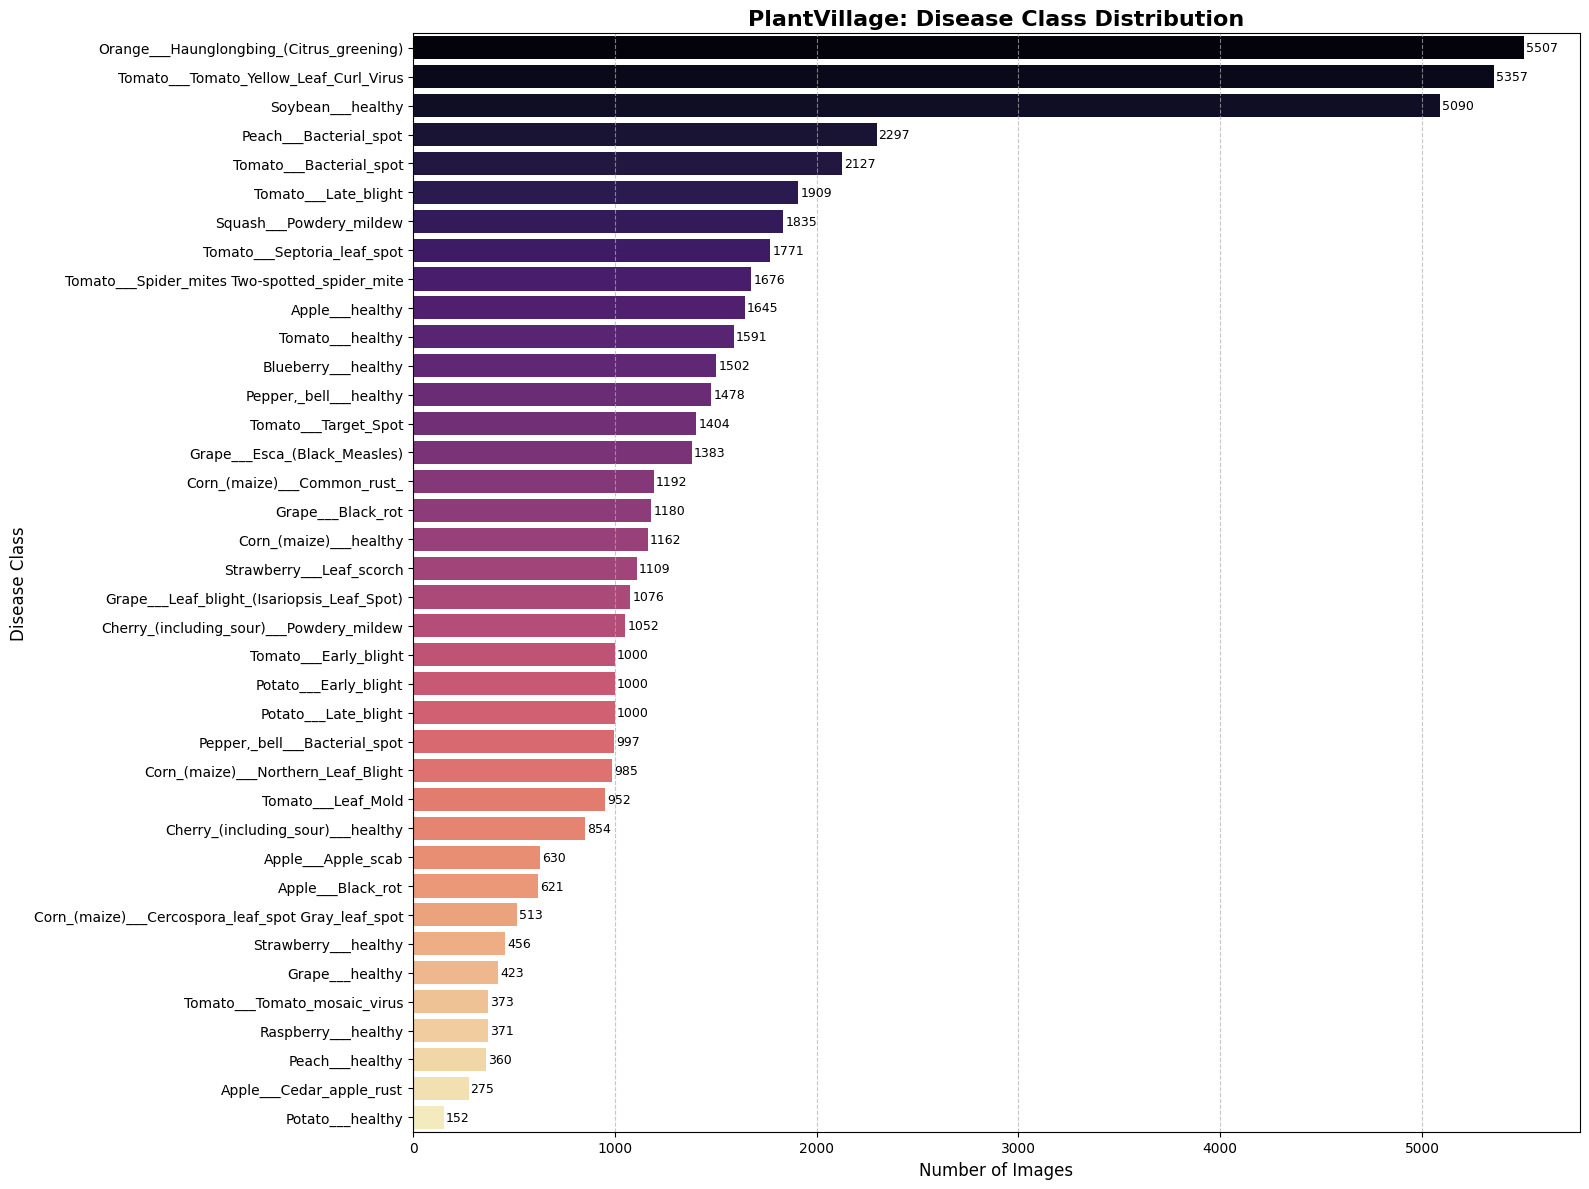


Displaying and saving random sample images...
✅ Saved -> EDA_Sample_Images.png


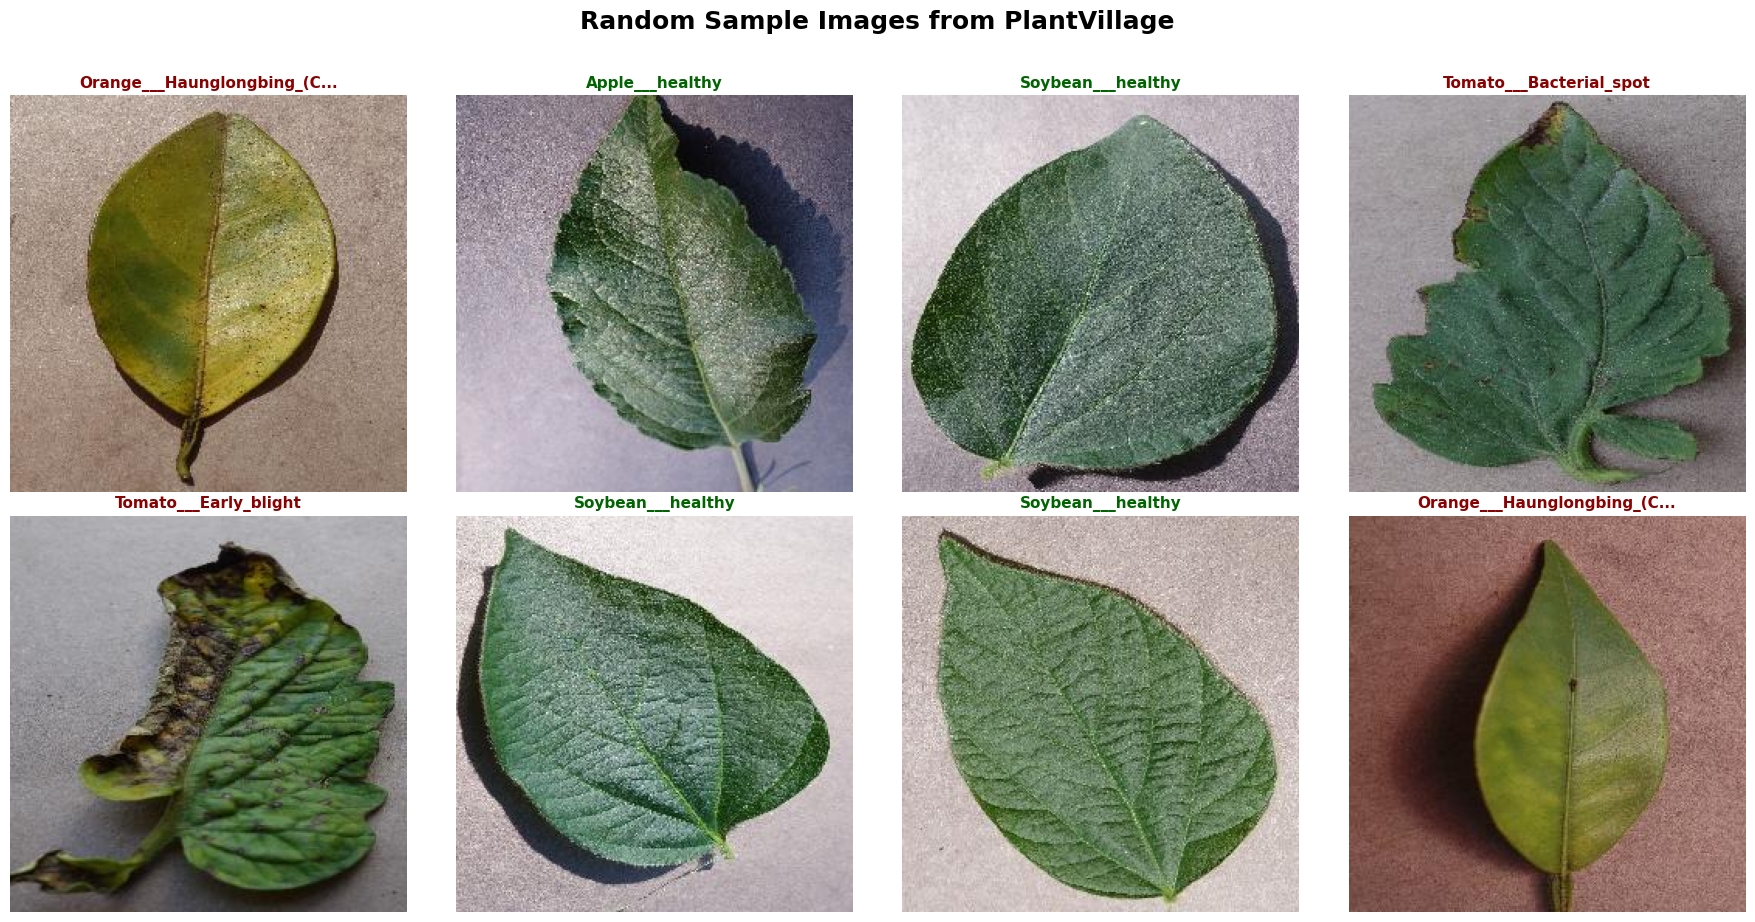


✅ Cell 3 Complete! EDA artifacts securely saved to disk.


In [6]:
# ==========================================
# CELL 3: ADVANCED EDA & ARTIFACT SAVING (FIXED)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random

print("Generating and saving EDA visualizations...")

# --- NEW: Reverse mapping to get string names from integers ---
idx_to_class = {v: k for k, v in class_to_idx.items()}

# 1. Class Distribution Plot
label_counts = df['label'].value_counts()
# Map the integer indices back to string names for the plot
class_names_for_plot = [idx_to_class[idx] for idx in label_counts.index]

plt.figure(figsize=(16, 12)) # Increased width to fix the tight_layout warning

# FIXED: Added 'hue' and 'legend=False' to clear the Seaborn warning
sns.barplot(
    x=label_counts.values, 
    y=class_names_for_plot, 
    hue=class_names_for_plot, 
    palette='magma', 
    legend=False
)

plt.title('PlantVillage: Disease Class Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Disease Class', fontsize=12)

# Add exact numbers to the end of each bar
for i, v in enumerate(label_counts.values):
    plt.text(v + 10, i, str(v), color='black', va='center', fontsize=9)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# CRITICAL: Save the figure before calling plt.show()
plt.savefig('EDA_Class_Distribution.png', dpi=150)
print("✅ Saved -> EDA_Class_Distribution.png")
plt.show()

# 2. Random Sample Images Grid
print("\nDisplaying and saving random sample images...")
sample_df = df.sample(8, random_state=random.randint(0, 10000))
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for idx, (index, row) in enumerate(sample_df.iterrows()):
    img_path = row['file_path']
    label_idx = row['label']
    
    # FIXED: Convert integer label back to string for visualization
    label_str = idx_to_class[label_idx] 
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    axes[idx].imshow(img)
    
    display_label = label_str[:25] + "..." if len(label_str) > 25 else label_str
    
    title_color = 'darkgreen' if 'healthy' in label_str.lower() else 'darkred'
    
    axes[idx].set_title(display_label, fontsize=11, fontweight='bold', color=title_color)
    axes[idx].axis('off')

plt.suptitle("Random Sample Images from PlantVillage", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig('EDA_Sample_Images.png', dpi=150, bbox_inches='tight')
print("✅ Saved -> EDA_Sample_Images.png")
plt.show()

print("\n✅ Cell 3 Complete! EDA artifacts securely saved to disk.")

In [7]:
# ==========================================
# CELL 4: COMPUTE CLASS WEIGHTS (PREP FOR STEP 3)
# ==========================================
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

print("Calculating optimal class weights to counter imbalance...")

# 1. We need the integer labels from our original dataframe
# Remember, 'df' has the 'label' column which contains the integer indices 
# because of how you set up Cell 1.
train_labels = train_df['label'].values

# 2. Compute weights using scikit-learn
# 'balanced' automatically adjusts weights inversely proportional to class frequencies
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# 3. Keras requires a dictionary mapping class indices to their weight
class_weight_dict = {i: weight for i, weight in enumerate(class_weights_array)}

# Let's peek at the weights for the extremes
idx_to_class = {v: k for k, v in class_to_idx.items()}

# Find index of max and min classes based on the EDA graph
largest_class_idx = class_to_idx['Orange___Haunglongbing_(Citrus_greening)']
smallest_class_idx = class_to_idx['Potato___healthy']

print(f"\nWeight for Majority Class ({idx_to_class[largest_class_idx]}): {class_weight_dict[largest_class_idx]:.4f}")
print(f"Weight for Minority Class ({idx_to_class[smallest_class_idx]}): {class_weight_dict[smallest_class_idx]:.4f}")

print("\n✅ Cell 4 Complete! Class weights are ready for the training loop.")

Calculating optimal class weights to counter imbalance...

Weight for Majority Class (Orange___Haunglongbing_(Citrus_greening)): 0.2595
Weight for Minority Class (Potato___healthy): 9.4372

✅ Cell 4 Complete! Class weights are ready for the training loop.


In [ ]:
# ==========================================
# CELL 5: TRAINING STRATEGY & EXECUTION (ANTI-NAN FIX)
# ==========================================
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import optimizers

print("1. Clearing poisoned Keras session...")
tf.keras.backend.clear_session()

print("2. Disabling Mixed Precision (Reverting to float32)...")
tf.keras.mixed_precision.set_global_policy('float32')

print("3. Rebuilding Model in pure float32 to clear NaN weights...")
with strategy.scope():
    # Rebuild the model fresh
    model_glcam = build_comparative_model(NUM_CLASSES, attention_type='glcam')
    
    # Ultra-safe learning rate for custom attention mechanisms
    bulletproof_lr = 1e-4 
    
    model_glcam.compile(
        optimizer=optimizers.Adam(learning_rate=bulletproof_lr, clipnorm=1.0),
        # from_logits=True is required since we removed the Softmax activation in Cell 2
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )

print("\n4. Configuring Training Callbacks...")
EPOCHS = 20

callbacks_list = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=5, mode='max', restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath='best_glcam_model.keras', monitor='val_accuracy', mode='max', save_best_only=True, verbose=1)
]

print(f"\n🚀 Restarting Training for {model_glcam.name} on Dual T4 GPUs...")
history_glcam = model_glcam.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_list,
    class_weight=class_weight_dict, 
    verbose=1
)

print("\n✅ Cell 5 Complete! Training finished successfully.")